# PCD — Klasifikasi Makanan Padang (Operasi Citra Klasik)

Pipeline berbasis operasi citra klasik untuk 9 kelas makanan Padang: segmentasi → fitur warna + tekstur → SVM.

Fitur utama:
- Segmentasi ROI makanan (threshold saturasi HSV / K-Means di Lab)
- Warna: histogram HSV + momen warna (Lab)
- Tekstur: LBP uniform multi-skala + GLCM (Haralick)
- Klasifikasi: SVM (grid search) + evaluasi k-fold / holdout
- Ablasi: warna saja, tekstur saja, gabungan, dengan/ tanpa segmentasi

Catatan: Notebook ini memfokuskan pada operasi citra untuk mata kuliah Pengolahan Citra Digital.

## Cara Pakai
- Pastikan dataset berada di folder `dataset_padang_food`, dengan struktur subfolder per kelas (mis. `dataset_padang_food/rendang`, `dataset_padang_food/ayam_goreng`, dst).
- Jalankan sel dari atas ke bawah.
- Atur konfigurasi pada sel "Konfigurasi" (segmentasi, fitur, PCA, CV).
- Gunakan sel ablation untuk membandingkan warna vs tekstur vs gabungan.

Jika beberapa paket belum terpasang, sel pertama akan mencoba meng-install otomatis.

### 1. Setup dependensi & pengecekan paket
Menyiapkan fungsi bantu untuk otomatis menginstal dependensi (numpy, opencv, scikit-image, dst.) dan mengimpor semua modul yang dipakai sepanjang notebook serta mengatur seed.


In [37]:
# Install dependensi jika belum tersedia (opsional)
import sys, subprocess
def pip_install(pkg):
    try:
        print(f'Installing {pkg} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
    except Exception as e:
        print(f'Warning: gagal install {pkg}: {e}')

# Coba import, jika gagal baru install
try:
    import numpy as np
    import cv2
    import skimage
    import sklearn
    import matplotlib
except Exception:
    pip_install('numpy')
    pip_install('opencv-python')
    pip_install('scikit-image')
    pip_install('scikit-learn')
    pip_install('matplotlib')
    pip_install('seaborn')
    pip_install('tqdm')

# Import ulang pasca install
import os, math, random, json, time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import color, feature, filters, morphology, measure, exposure
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
try:
    import seaborn as sns
except Exception:
    sns = None
try:
    from tqdm import tqdm
except Exception:
    tqdm = lambda x, **kw: x

SEED = 42
random.seed(SEED); np.random.seed(SEED)

print('Versions:')
print('numpy', np.__version__)
print('cv2', cv2.__version__)
import skimage, sklearn
print('skimage', skimage.__version__)
print('sklearn', sklearn.__version__)


Versions:
numpy 1.26.4
cv2 4.11.0
skimage 0.25.2
sklearn 1.6.1


### 2. Konfigurasi eksperimen & parameter
Mengatur seluruh parameter global: lokasi dataset, opsi segmentasi, ambang HSV, ukuran kernel morfologi, konfigurasi fitur, hingga parameter evaluasi (split, PCA, dsb.).


In [38]:
# Konfigurasi
dataset_dir = 'dataset_padang_food'  # ganti jika lokasi berbeda
img_size = 384                 # sisi pendek di-resize proporsional
use_segmentation = True        # gunakan segmentasi ROI makanan
segmentation_method = 'saturation'  # 'saturation' atau 'kmeans'
preprocess_blur_ksize = (5, 5)  # kernel blur ringan untuk meredam noise sebelum segmentasi
preprocess_blur_sigma = 0       # sigma blur Gaussian
sv_s_min = 60                   # ambang minimal saturasi agar dianggap makanan
sv_v_min = 50                   # ambang minimal value (kecerahan)
morph_kernel_size = 5           # ukuran kernel morfologi untuk opening/closing
morph_open_iters = 1            # jumlah iterasi opening
morph_close_iters = 2           # jumlah iterasi closing


# Pilihan fitur
use_hist_hsv = True
use_color_moments = True
use_lbp = True
use_glcm = True
use_gabor = False  # opsional, menambah waktu komputasi

# Klasifikasi & evaluasi
use_pca = True
pca_var = 0.95
test_size = 0.2
cv_folds = 5
random_state = SEED

# LBP parameter
lbp_radii = [1, 2, 3]
lbp_points = [8, 16, 24]
lbp_method = 'uniform'

# GLCM parameter
glcm_distances = [1, 2, 3]
glcm_angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
glcm_props = ['contrast', 'homogeneity', 'energy', 'correlation', 'dissimilarity']

# Histogram HSV bin
h_bins, s_bins, v_bins = 12, 4, 4

### 3. Memuat dataset dan utilitas tampilan
Mendefinisikan helper untuk membaca gambar, menampilkan sampel, dan menghasilkan daftar path/label sehingga seluruh pipeline tahu kelas apa saja yang tersedia.


Kelas: ['ayam_goreng', 'ayam_pop', 'daging_rendang', 'dendeng_batokok', 'gulai_ikan', 'gulai_tambusu', 'gulai_tunjang', 'telur_balado', 'telur_dadar']
Jumlah gambar: 783
Distribusi: Counter({'telur_dadar': 105, 'daging_rendang': 91, 'gulai_tunjang': 90, 'dendeng_batokok': 89, 'gulai_ikan': 88, 'gulai_tambusu': 86, 'ayam_goreng': 80, 'ayam_pop': 79, 'telur_balado': 75})


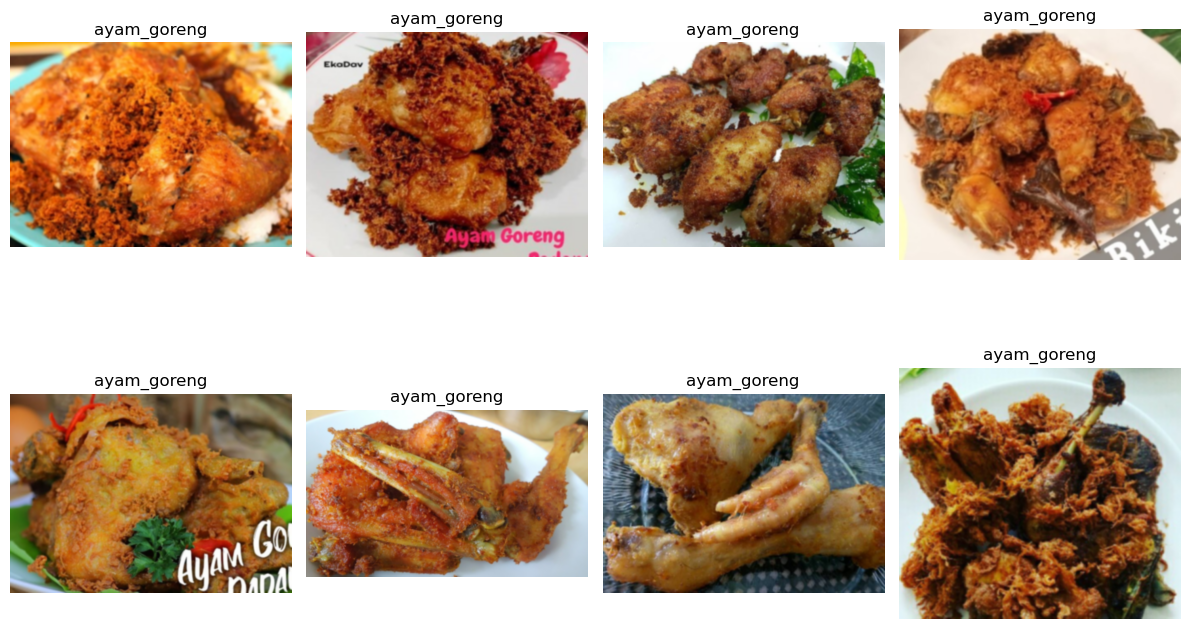

In [39]:
# Utilitas IO & tampilan
def list_image_paths(root):
    classes = []
    paths = []
    if not os.path.isdir(root):
        raise FileNotFoundError(f'Folder tidak ditemukan: {root}')
    for d in sorted(os.listdir(root)):
        dd = os.path.join(root, d)
        if os.path.isdir(dd):
            files = []
            for fn in os.listdir(dd):
                if fn.lower().endswith(('.jpg','.jpeg','.png','.bmp','.tif','.tiff')):
                    files.append(os.path.join(dd, fn))
            if files:
                classes.append(d)
                for f in files:
                    paths.append((f, d))
    if not paths:
        raise RuntimeError('Tidak ada gambar ditemukan di subfolder kelas.')
    return classes, paths

def imread_resize(path, target_short=img_size):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise RuntimeError(f'Gagal membaca: {path}')
    h, w = img.shape[:2]
    short = min(h, w)
    scale = target_short / short
    nh, nw = int(round(h*scale)), int(round(w*scale))
    img = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)
    if preprocess_blur_ksize:
        img = cv2.GaussianBlur(img, preprocess_blur_ksize, preprocess_blur_sigma)
    return img

def show_imgs(imgs, cols=4, figsize=(12,8), titles=None):
    rows = math.ceil(len(imgs)/cols)
    plt.figure(figsize=figsize)
    for i, im in enumerate(imgs):
        plt.subplot(rows, cols, i+1)
        if im.ndim == 2:
            plt.imshow(im, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        if titles:
            plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

classes, all_paths = list_image_paths(dataset_dir)
class_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_class = {i:c for c,i in class_to_idx.items()}
print('Kelas:', classes)
print('Jumlah gambar:', len(all_paths))
from collections import Counter
cnt = Counter([y for _,y in all_paths])
print('Distribusi:', cnt)
# Tampilkan beberapa sampel
samples = []
titles = []
for p,y in all_paths[:min(8, len(all_paths))]:
    samples.append(imread_resize(p))
    titles.append(y)
show_imgs(samples, cols=4, titles=titles)


### 4. Fungsi preprocessing warna & segmentasi
Berisi definisi blur opsional, fungsi gray-world (masih tersedia bila ingin dipakai), serta dua metode segmentasi utama (HSV threshold dan K-Means Lab) lengkap dengan post-processing mask.


In [40]:
# Color constancy dan Segmentasi
def gray_world(img_bgr):
    img = img_bgr.astype(np.float32)
    mean_bgr = img.reshape(-1,3).mean(axis=0)
    gray_val = np.mean(mean_bgr) + 1e-6
    scale = gray_val / (mean_bgr + 1e-6)
    img *= scale
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

# Segmentasi berbasis HSV (S & V tinggi)
def segment_by_saturation(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    s = hsv[:,:,1]
    v = hsv[:,:,2]
    s_blur = cv2.GaussianBlur(s, (3,3), 0)
    v_blur = cv2.GaussianBlur(v, (3,3), 0)
    s_mask = (s_blur >= sv_s_min).astype(np.uint8) * 255
    v_mask = (v_blur >= sv_v_min).astype(np.uint8) * 255
    mask = cv2.bitwise_and(s_mask, v_mask)
    return postprocess_mask(mask)

# Opsional: segmentasi Lab + KMeans tetap tersedia
def segment_by_kmeans_lab(img_bgr, k=3, attempts=3):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    ab = lab[:,:,1:3].reshape(-1,2).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 40, 1.0)
    _, labels, centers = cv2.kmeans(ab, k, None, criteria, attempts, cv2.KMEANS_PP_CENTERS)
    labels = labels.reshape(lab.shape[:2])
    mask_scores = []
    for ci in range(k):
        m = (labels==ci)
        if m.sum() == 0:
            mask_scores.append((-1, ci))
            continue
        ab_ci = ab[labels.reshape(-1)==ci]
        var = ab_ci.var()
        mask_scores.append((var, ci))
    mask_scores.sort(reverse=True)
    best_ci = mask_scores[0][1] if mask_scores else 0
    mask = (labels==best_ci).astype(np.uint8)
    return postprocess_mask(mask)

# Bersihkan mask dan ambil komponen terbesar
def postprocess_mask(mask):
    mask255 = (mask > 0).astype(np.uint8) * 255
    kernel = np.ones((morph_kernel_size, morph_kernel_size), np.uint8)
    if morph_open_iters > 0:
        mask255 = cv2.morphologyEx(mask255, cv2.MORPH_OPEN, kernel, iterations=morph_open_iters)
    if morph_close_iters > 0:
        mask255 = cv2.morphologyEx(mask255, cv2.MORPH_CLOSE, kernel, iterations=morph_close_iters)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask255, connectivity=8)
    if num_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]
        largest = 1 + np.argmax(areas)
        mask255 = np.where(labels == largest, 255, 0).astype(np.uint8)
    return (mask255 > 0).astype(np.uint8)

def get_mask(img_bgr, method='saturation'):
    if method == 'saturation':
        return segment_by_saturation(img_bgr)
    elif method == 'kmeans':
        return segment_by_kmeans_lab(img_bgr)
    else:
        return np.ones(img_bgr.shape[:2], dtype=np.uint8)



### 5. Definisi ekstraksi fitur warna/tekstur
Menguraikan semua extractor klasik (HSV histogram, momen Lab, LBP, GLCM, Gabor) yang awalnya digunakan untuk pendekatan berbasis fitur, sekaligus menjadi dasar statistik warna/tekstur.


In [41]:
# Ekstraksi fitur
def hsv_histogram(img_bgr, mask=None, bins=(12,4,4)):
    h_bins, s_bins, v_bins = bins
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h = cv2.calcHist([hsv],[0],mask, [h_bins],[0,180])
    s = cv2.calcHist([hsv],[1],mask, [s_bins],[0,256])
    v = cv2.calcHist([hsv],[2],mask, [v_bins],[0,256])
    hist = np.concatenate([h.flatten(), s.flatten(), v.flatten()]).astype(np.float32)
    if hist.sum() > 0:
        hist /= (hist.sum()+1e-8)
    return hist

def color_moments_lab(img_bgr, mask=None):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    feats = []
    if mask is not None:
        mask_bool = mask.astype(bool)
    else:
        mask_bool = slice(None)
    for c in range(3):
        ch = lab[:,:,c]
        vals = ch[mask_bool].astype(np.float32).ravel()
        if vals.size == 0:
            vals = ch.astype(np.float32).ravel()
        mean = vals.mean()
        std = vals.std()
        skew = ((vals - mean)**3).mean() / (std**3 + 1e-8)
        feats.extend([mean, std, skew])
    return np.array(feats, dtype=np.float32)

def lbp_features(gray, mask=None, radii=[1,2,3], points=[8,16,24], method='uniform'):
    feats = []
    if mask is not None:
        mask_bool = mask.astype(bool)
    else:
        mask_bool = None
    for r, p in zip(radii, points):
        lbp = local_binary_pattern(gray, p, r, method=method)
        if method == 'uniform':
            n_bins = p + 2
        else:
            n_bins = int(lbp.max()+1)
        if mask_bool is not None:
            vals = lbp[mask_bool].ravel()
        else:
            vals = lbp.ravel()
        hist, _ = np.histogram(vals, bins=n_bins, range=(0, n_bins), density=True)
        feats.extend(hist.tolist())
    return np.array(feats, dtype=np.float32)

def glcm_features(gray, mask=None, distances=[1,2,3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], props=None):
    if props is None:
        props = ['contrast','homogeneity','energy','correlation','dissimilarity']
    # Kuantisasi ke 8-bit untuk GLCM
    img = gray
    if mask is not None:
        img = img.copy()
        img[mask==0] = 0
    img8 = exposure.rescale_intensity(img, out_range=(0,255)).astype(np.uint8)
    glcm = graycomatrix(img8, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)
    feats = []
    for pr in props:
        vals = graycoprops(glcm, pr).ravel()
        feats.extend([vals.mean(), vals.std()])
    return np.array(feats, dtype=np.float32)

def gabor_bank_features(gray, mask=None, n_orient=4, n_scales=3):
    feats = []
    rows, cols = gray.shape
    thetas = np.linspace(0, np.pi, n_orient, endpoint=False)
    sigmas = np.linspace(1.0, 3.0, n_scales)
    for th in thetas:
        for sg in sigmas:
            kern = cv2.getGaborKernel((21,21), sg, th, 10, 0.5, 0, ktype=cv2.CV_32F)
            resp = cv2.filter2D(gray, cv2.CV_32F, kern)
            if mask is not None:
                vals = resp[mask>0] if np.any(mask) else resp.ravel()
            else:
                vals = resp.ravel()
            feats.extend([float(np.mean(vals)), float(np.std(vals))])
    return np.array(feats, dtype=np.float32)

def extract_features(img_bgr, mask=None):
    feats = []
    if use_hist_hsv:
        feats.append(hsv_histogram(img_bgr, mask, bins=(h_bins, s_bins, v_bins)))
    if use_color_moments:
        feats.append(color_moments_lab(img_bgr, mask))
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    if use_lbp:
        feats.append(lbp_features(gray, mask, lbp_radii, lbp_points, lbp_method))
    if use_glcm:
        feats.append(glcm_features(gray, mask, glcm_distances, glcm_angles, glcm_props))
    if use_gabor:
        feats.append(gabor_bank_features(gray, mask))
    return np.concatenate(feats, axis=0).astype(np.float32)


### 5a. Fitur ringkas untuk rule-based classifier
Membangun deskriptor warna (proporsi H/S/V), tekstur (rasio LBP uniform vs kasar), dan bentuk (area, aspect, roundness, extent) yang akan digunakan untuk aturan rule-based.


In [42]:
# Ringkasan fitur warna/tekstur/bentuk untuk rule-based
def compute_shape_features(mask):
    mask_bin = (mask > 0).astype(np.uint8)
    total_area = mask_bin.size
    area = float(mask_bin.sum())
    if area <= 0:
        return dict(area_ratio=0.0, aspect_ratio=1.0, extent=0.0, roundness=0.0)
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return dict(area_ratio=0.0, aspect_ratio=1.0, extent=0.0, roundness=0.0)
    cnt = max(contours, key=cv2.contourArea)
    perimeter = cv2.arcLength(cnt, True)
    x, y, w, h = cv2.boundingRect(cnt)
    aspect = w / h if w >= h and h > 0 else (h / w if w > 0 else 1.0)
    extent = area / float((w * h) + 1e-8)
    roundness = (4.0 * np.pi * area) / (perimeter**2 + 1e-8) if perimeter > 0 else 0.0
    area_ratio = area / float(total_area + 1e-8)
    return dict(area_ratio=float(area_ratio), aspect_ratio=float(aspect), extent=float(extent), roundness=float(roundness))

def extract_rule_descriptors(img_bgr, mask):
    if mask is None:
        mask = np.ones(img_bgr.shape[:2], dtype=np.uint8)
    mask_bin = (mask > 0).astype(np.uint8)
    if mask_bin.sum() == 0:
        mask_bin[:] = 1
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h_hist = cv2.calcHist([hsv], [0], mask_bin, [h_bins], [0, 180]).flatten().astype(np.float32)
    s_hist = cv2.calcHist([hsv], [1], mask_bin, [s_bins], [0, 256]).flatten().astype(np.float32)
    v_hist = cv2.calcHist([hsv], [2], mask_bin, [v_bins], [0, 256]).flatten().astype(np.float32)
    for hist in (h_hist, s_hist, v_hist):
        total = hist.sum()
        if total > 0:
            hist /= total
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, 8, 1, method='uniform')
    mask_bool = mask_bin.astype(bool)
    if mask_bool.any():
        vals = lbp[mask_bool]
    else:
        vals = lbp.ravel()
    lbp_bins = 8 + 2
    lbp_hist, _ = np.histogram(vals, bins=lbp_bins, range=(0, lbp_bins), density=True)
    uniform_ratio = float(np.clip(lbp_hist[:-1].sum(), 0.0, 1.0))
    center_ratio = float(np.clip(lbp_hist[0], 0.0, 1.0))
    texture_rough = float(max(0.0, 1.0 - uniform_ratio))
    shape_feats = compute_shape_features(mask_bin)
    feats = {
        'h_hist': h_hist,
        's_hist': s_hist,
        'v_hist': v_hist,
        'color_red': float(h_hist[0] + h_hist[1]),
        'color_yellow': float(h_hist[2] + h_hist[3]),
        'color_green': float(h_hist[4] + h_hist[5]),
        'sat_high': float(s_hist[2] + s_hist[3]),
        'sat_mid': float(s_hist[1]),
        'sat_low': float(s_hist[0]),
        'val_dark': float(v_hist[0]),
        'val_mid': float(v_hist[1]),
        'val_bright': float(v_hist[2] + v_hist[3]),
        'texture_uniform': uniform_ratio,
        'texture_center': center_ratio,
        'texture_rough': texture_rough,
    }
    feats.update({
        'shape_area_ratio': shape_feats['area_ratio'],
        'shape_aspect_ratio': shape_feats['aspect_ratio'],
        'shape_extent': shape_feats['extent'],
        'shape_roundness': shape_feats['roundness'],
    })
    return feats


### 6. Visualisasi tahapan preprocessing
Menampilkan contoh citra pada setiap tahap yang kini digunakan (original → resize → blur) sehingga efek pra-pemrosesan tanpa gray-world bisa diamati.


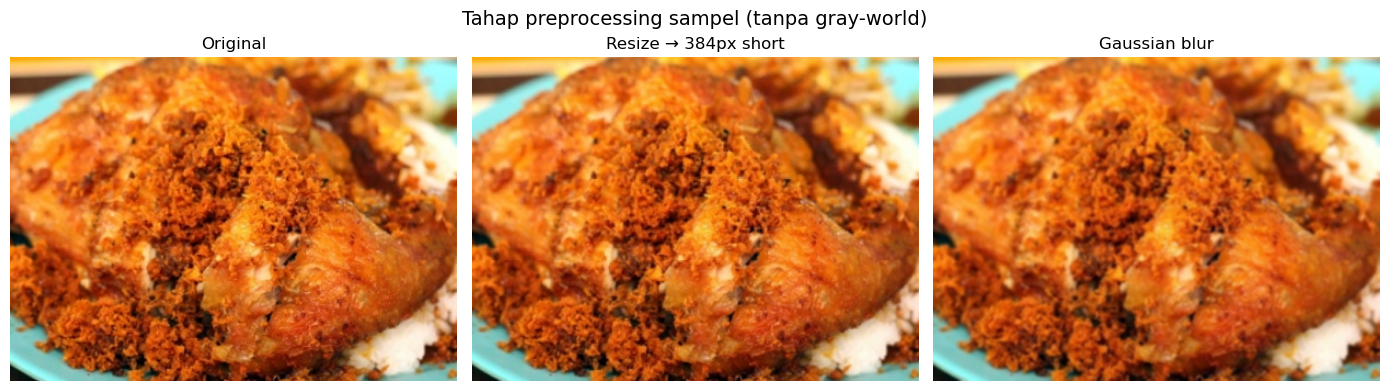

In [43]:
# Visualisasi preprocessing (original → resize → blur)
if not all_paths:
    raise RuntimeError('Dataset kosong, tidak bisa memvisualisasikan preprocessing.')
sample_path = all_paths[0][0]
orig = cv2.imread(sample_path, cv2.IMREAD_COLOR)
h, w = orig.shape[:2]
short = min(h, w)
scale = img_size / short
resized = cv2.resize(orig, (int(round(w*scale)), int(round(h*scale))), interpolation=cv2.INTER_AREA)
blurred = cv2.GaussianBlur(resized, preprocess_blur_ksize, preprocess_blur_sigma) if preprocess_blur_ksize else resized.copy()
titles = ['Original', f'Resize → {img_size}px short', 'Gaussian blur']
images = [orig, resized, blurred]
fig, axes = plt.subplots(1, len(images), figsize=(14,4))
for ax, im, ttl in zip(axes, images, titles):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(ttl)
    ax.axis('off')
fig.suptitle('Tahap preprocessing sampel (tanpa gray-world)', fontsize=14)
plt.tight_layout()


### 7. Visualisasi fitur warna & tekstur
Menunjukkan citra setelah preprocessing terbaru (tanpa gray-world) beserta mask, histogram HSV, dan distribusi LBP untuk memvalidasi pipeline fitur.


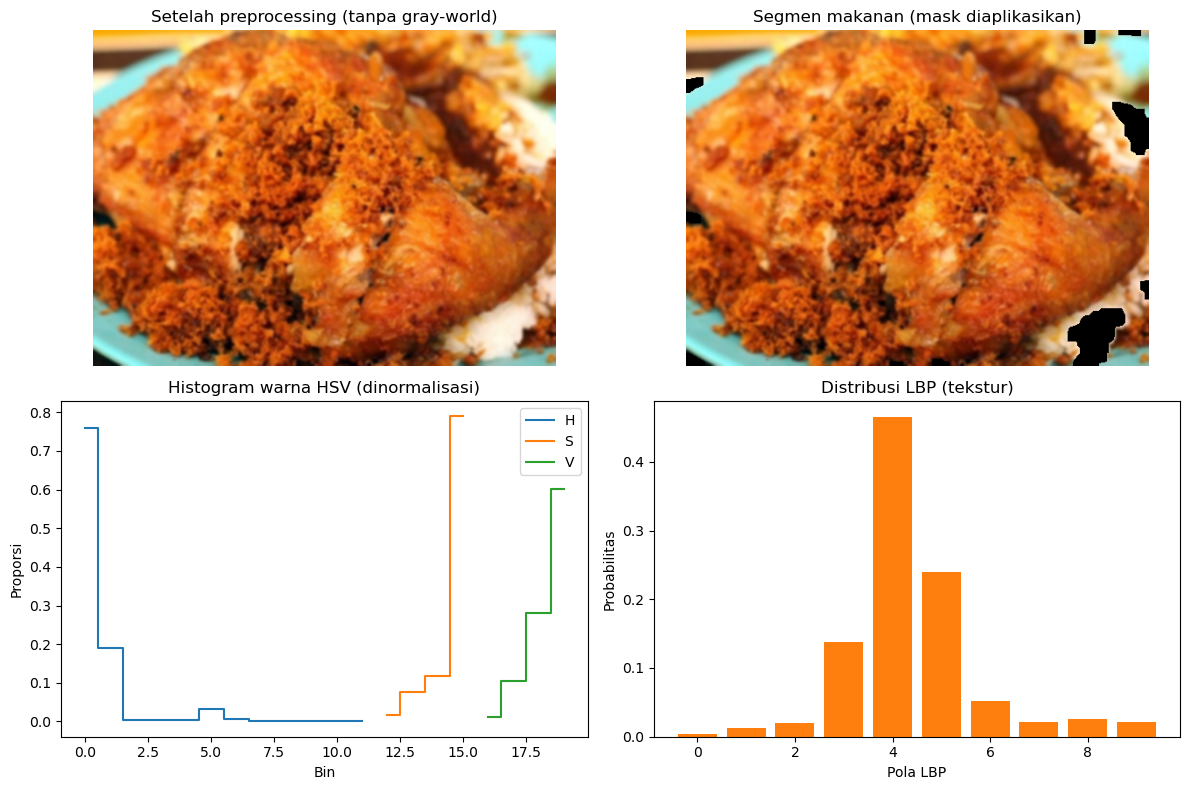

In [44]:
# Visualisasi fitur warna & tekstur untuk satu sampel
if not all_paths:
    raise RuntimeError('Dataset kosong, tidak bisa memvisualisasikan fitur.')
feat_path = all_paths[0][0]
img = imread_resize(feat_path)
img_proc = img.copy()
mask = get_mask(img_proc, method=segmentation_method) if use_segmentation else np.ones(img_proc.shape[:2], dtype=np.uint8)
segmented = cv2.bitwise_and(img_proc, img_proc, mask=mask)
hsv = cv2.cvtColor(img_proc, cv2.COLOR_BGR2HSV)
h_hist = cv2.calcHist([hsv],[0],mask,[h_bins],[0,180]).flatten()
s_hist = cv2.calcHist([hsv],[1],mask,[s_bins],[0,256]).flatten()
v_hist = cv2.calcHist([hsv],[2],mask,[v_bins],[0,256]).flatten()
for hist in (h_hist, s_hist, v_hist):
    total = hist.sum() + 1e-9
    hist /= total
gray = cv2.cvtColor(img_proc, cv2.COLOR_BGR2GRAY)
lbp = local_binary_pattern(gray, lbp_points[0], lbp_radii[0], method=lbp_method)
n_bins = lbp_points[0] + 2 if lbp_method == 'uniform' else int(lbp.max()+1)
lbp_vals = lbp[mask.astype(bool)] if mask is not None else lbp.ravel()
lbp_hist, _ = np.histogram(lbp_vals, bins=n_bins, range=(0, n_bins), density=True)
fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes[0,0].imshow(cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB))
axes[0,0].set_title('Setelah preprocessing (tanpa gray-world)')
axes[0,0].axis('off')
axes[0,1].imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
axes[0,1].set_title('Segmen makanan (mask diaplikasikan)')
axes[0,1].axis('off')
axes[1,0].step(range(len(h_hist)), h_hist, where='mid', label='H')
axes[1,0].step(range(len(h_hist), len(h_hist)+len(s_hist)), s_hist, where='mid', label='S')
axes[1,0].step(range(len(h_hist)+len(s_hist), len(h_hist)+len(s_hist)+len(v_hist)), v_hist, where='mid', label='V')
axes[1,0].set_title('Histogram warna HSV (dinormalisasi)')
axes[1,0].legend()
axes[1,0].set_xlabel('Bin')
axes[1,0].set_ylabel('Proporsi')
axes[1,1].bar(range(len(lbp_hist)), lbp_hist, color='tab:orange')
axes[1,1].set_title('Distribusi LBP (tekstur)')
axes[1,1].set_xlabel('Pola LBP')
axes[1,1].set_ylabel('Probabilitas')
plt.tight_layout()


### 8. Bangun dataset rule-based + preview segmentasi
Membangun dataset rule-based langsung dari citra hasil resize/blur; setiap entri menyimpan path, label, dan fitur ringkas sekaligus menampilkan preview mask.


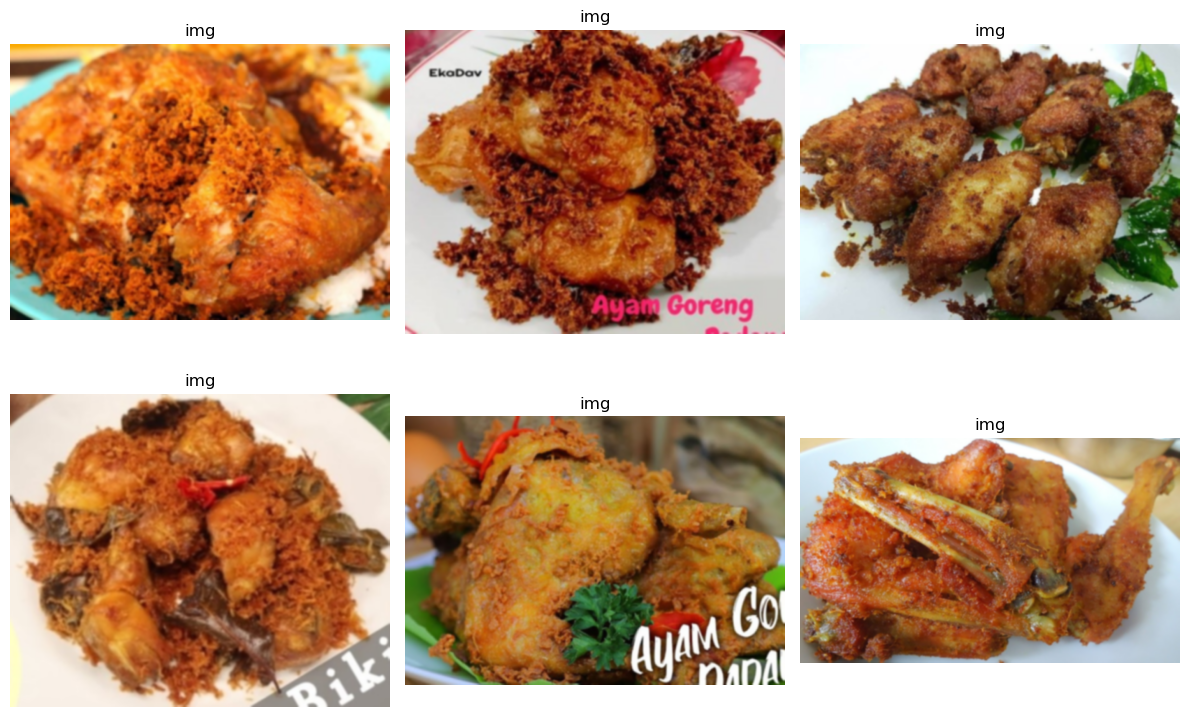

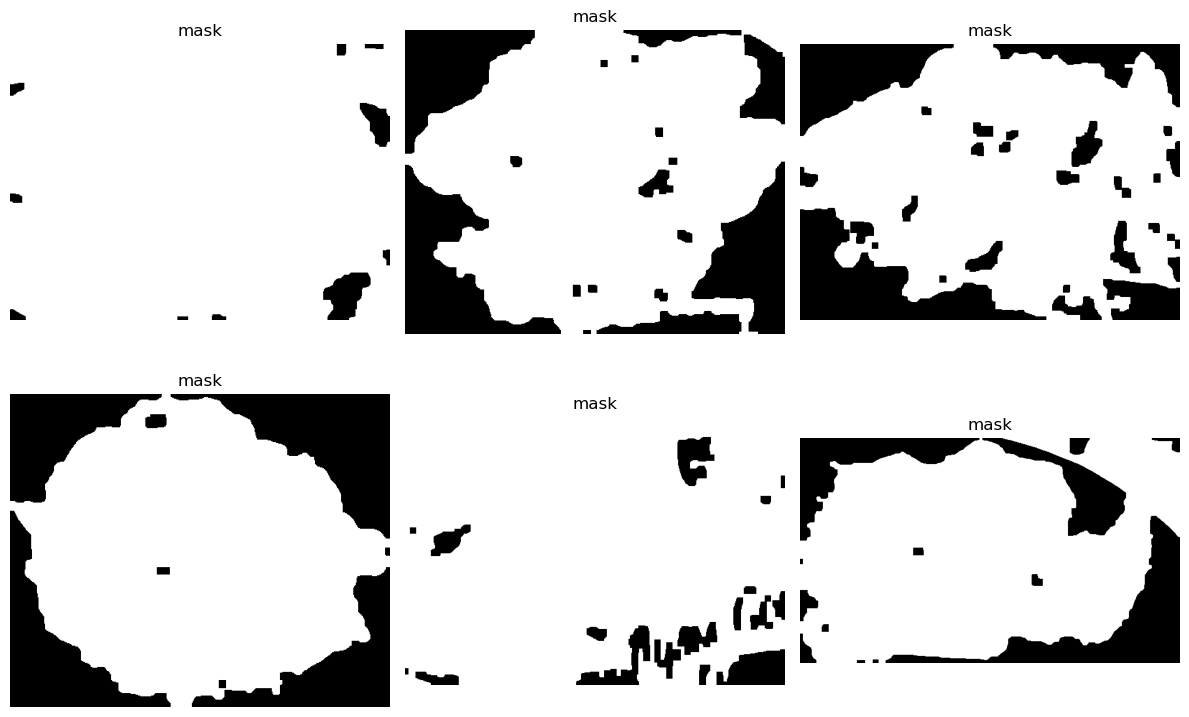

In [45]:
# Bangun dataset fitur
def build_rule_dataset(paths_labels, seg_method=None):
    data = []
    for p, yc in tqdm(paths_labels, desc='Rule features', total=len(paths_labels)):
        img = imread_resize(p, target_short=img_size)
        if seg_method is not None:
            mask = get_mask(img, method=seg_method)
        else:
            mask = np.ones(img.shape[:2], dtype=np.uint8)
        if mask is None or mask.sum() == 0:
            mask = np.ones(img.shape[:2], dtype=np.uint8)
        feats = extract_rule_descriptors(img, mask)
        data.append({'path': p, 'label': yc, 'features': feats})
    return data

# Contoh preview segmentasi pada beberapa gambar
preview_imgs = []
preview_masks = []
for p,_ in all_paths[:min(6,len(all_paths))]:
    img = imread_resize(p, target_short=img_size)
    m = get_mask(img, method=segmentation_method) if use_segmentation else np.ones(img.shape[:2], dtype=np.uint8)
    preview_imgs.append(img)
    preview_masks.append(m*255)
show_imgs(preview_imgs, cols=3, titles=['img']*len(preview_imgs))
show_imgs([cv2.cvtColor(m, cv2.COLOR_GRAY2BGR) for m in preview_masks], cols=3, titles=['mask']*len(preview_masks))


### 9. (Opsional) Builder fitur klasik
Versi lama untuk menyusun matriks fitur klasik (HSV/LBP/GLCM) apabila ingin eksperimen lain; tidak dipakai di pipeline rule-based namun disimpan sebagai referensi.


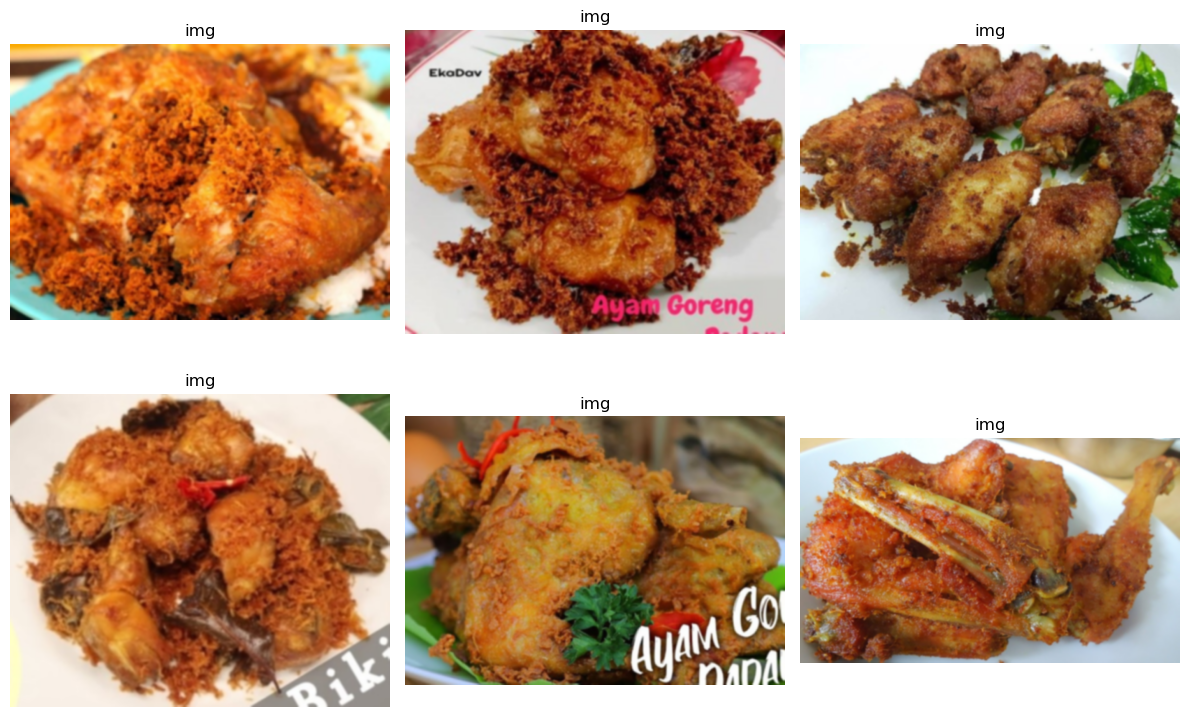

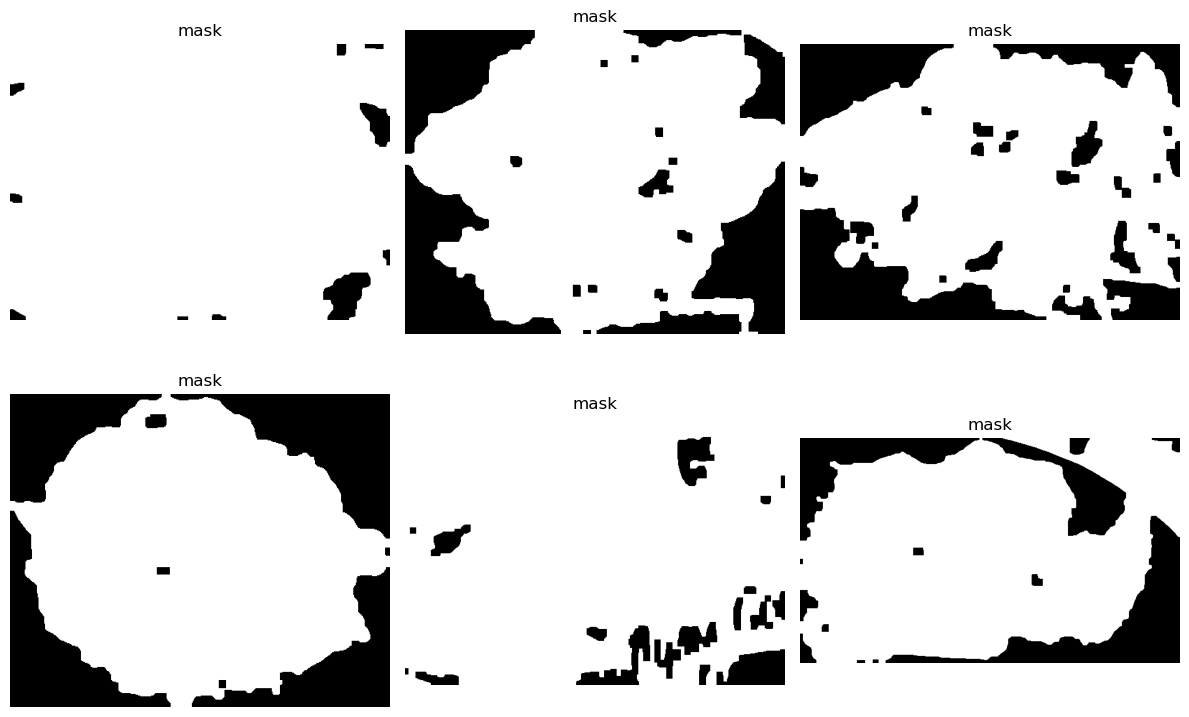

In [46]:
# Bangun dataset fitur
def build_dataset(paths_labels, seg_method=None):
    X = []
    y = []
    for p,yc in tqdm(paths_labels, desc='Extracting', total=len(paths_labels)):
        img = imread_resize(p, target_short=img_size)
        mask = None
        if seg_method is not None:
            mask = get_mask(img, method=seg_method)
        feats = extract_features(img, mask)
        X.append(feats)
        y.append(class_to_idx[yc])
    X = np.vstack(X).astype(np.float32)
    y = np.array(y, dtype=np.int64)
    return X, y

# Contoh preview segmentasi pada beberapa gambar
preview_imgs = []
preview_masks = []
for p,_ in all_paths[:min(6,len(all_paths))]:
    img = imread_resize(p, target_short=img_size)
    m = get_mask(img, method=segmentation_method) if use_segmentation else np.ones(img.shape[:2], dtype=np.uint8)
    preview_imgs.append(img)
    preview_masks.append(m*255)
show_imgs(preview_imgs, cols=3, titles=['img']*len(preview_imgs))
show_imgs([cv2.cvtColor(m, cv2.COLOR_GRAY2BGR) for m in preview_masks], cols=3, titles=['mask']*len(preview_masks))


### 10. Evaluasi classifier rule-based
Mendefinisikan fungsi penilaian berbasis aturan (warna/tekstur/bentuk), mencetak metrik, dan menggambar confusion matrix.


In [47]:
# Rule-based evaluasi
def bool_weight(cond, weight):
    return weight if cond else 0.0

def classify_rule(feats, components=None):
    if components is None:
        components = {'color': True, 'texture': True, 'shape': True}
    color_factor = 1.0 if components.get('color', True) else 0.0
    texture_factor = 1.0 if components.get('texture', True) else 0.0
    shape_factor = 1.0 if components.get('shape', True) else 0.0
    red = feats['color_red']
    yellow = feats['color_yellow']
    green = feats['color_green']
    sat_high = feats['sat_high']
    sat_mid = feats['sat_mid']
    sat_low = feats['sat_low']
    val_dark = feats['val_dark']
    val_mid = feats['val_mid']
    val_bright = feats['val_bright']
    texture_uniform = feats['texture_uniform']
    texture_rough = feats['texture_rough']
    roundness = feats['shape_roundness']
    area_ratio = feats['shape_area_ratio']
    aspect = feats['shape_aspect_ratio']
    extent = feats['shape_extent']
    scores = {}
    scores['ayam_goreng'] = (
        color_factor * (2.0 * red + 1.0 * yellow + 0.8 * sat_high + 0.6 * val_mid)
        + texture_factor * (0.7 * texture_rough)
        + shape_factor * (0.4 * (1 - roundness) + bool_weight(aspect > 1.25, 0.3))
    )
    scores['ayam_pop'] = (
        color_factor * (0.8 * red + 0.9 * yellow + 1.2 * sat_low + 0.6 * val_bright)
        + texture_factor * (0.8 * texture_uniform)
        + shape_factor * (bool_weight(roundness > 0.35, 0.6) + bool_weight(area_ratio > 0.25, 0.4))
    )
    scores['daging_rendang'] = (
        color_factor * (2.2 * red + 0.5 * sat_high + 1.5 * val_dark)
        + texture_factor * (1.0 * texture_rough)
        + shape_factor * (bool_weight(roundness < 0.4, 0.8) + bool_weight(area_ratio < 0.3, 0.6))
    )
    scores['dendeng_batokok'] = (
        color_factor * (1.7 * red + 0.6 * yellow + 0.7 * val_mid)
        + texture_factor * (0.9 * texture_rough)
        + shape_factor * (bool_weight(aspect > 1.6, 0.8) + bool_weight(extent < 0.5, 0.4))
    )
    scores['gulai_ikan'] = (
        color_factor * (2.0 * yellow + 0.8 * sat_high + 0.5 * val_mid)
        + texture_factor * (0.4 * texture_uniform + 0.4 * texture_rough)
        + shape_factor * (bool_weight(aspect > 1.4, 0.9) + bool_weight(area_ratio > 0.3, 0.5))
    )
    scores['gulai_tambusu'] = (
        color_factor * (1.8 * yellow + 0.9 * sat_mid + 0.4 * val_mid)
        + texture_factor * (0.8 * texture_uniform)
        + shape_factor * (bool_weight(0.3 < roundness < 0.6, 0.7) + bool_weight(extent > 0.45, 0.4))
    )
    scores['gulai_tunjang'] = (
        color_factor * (1.6 * yellow + 0.7 * sat_high + 1.1 * val_bright)
        + texture_factor * (0.5 * texture_uniform)
        + shape_factor * (bool_weight(area_ratio > 0.45, 0.9) + bool_weight(extent > 0.55, 0.6))
    )
    scores['telur_balado'] = (
        color_factor * (2.2 * red + 1.2 * sat_high + 0.7 * val_mid)
        + texture_factor * (0.6 * texture_uniform)
        + shape_factor * (bool_weight(roundness > 0.6, 1.0) + bool_weight(area_ratio > 0.2, 0.5))
    )
    scores['telur_dadar'] = (
        color_factor * (1.9 * yellow + 0.9 * sat_mid + 1.0 * val_bright)
        + texture_factor * (0.7 * texture_uniform)
        + shape_factor * (bool_weight(roundness > 0.55, 0.9) + bool_weight(extent > 0.6, 0.5))
    )
    return max(scores.items(), key=lambda kv: kv[1])[0]

def evaluate_rule_based(data, components=None, verbose=True):
    y_true = [item['label'] for item in data]
    y_pred = [classify_rule(item['features'], components=components) for item in data]
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro', labels=classes, zero_division=0) if len(set(y_true)) > 1 else 0.0
    if verbose:
        print(f'Rule-based Accuracy: {acc:.4f} | Macro F1: {f1m:.4f}')
        print('Classification Report:')
        print(classification_report(y_true, y_pred, labels=classes, target_names=classes, zero_division=0))
        cm = confusion_matrix(y_true, y_pred, labels=classes)
        plt.figure(figsize=(8,6))
        if sns is not None:
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
        else:
            plt.imshow(cm, cmap='Blues'); plt.colorbar()
            plt.xticks(range(len(classes)), classes, rotation=45, ha='right')
            plt.yticks(range(len(classes)), classes)
            for (i,j),v in np.ndenumerate(cm):
                plt.text(j,i,str(v),ha='center',va='center')
        plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix - Rule-based')
        plt.tight_layout(); plt.show()
    return {'accuracy': acc, 'macro_f1': f1m, 'y_true': y_true, 'y_pred': y_pred}



### 11. Skenario ablation experiment
Menjalankan eksperimen kombinasi komponen (warna saja, tekstur saja, dst.) untuk melihat kontribusi masing-masing terhadap rule scoring.


In [48]:
# Runner ablation
def ensure_rule_data(data=None):
    if data is not None:
        return data
    seg = segmentation_method if use_segmentation else None
    return build_rule_dataset(all_paths, seg_method=seg)

def quick_ablation(data=None):
    dataset = ensure_rule_data(data)
    configs = [
        ('Color only', {'texture': False, 'shape': False}),
        ('Texture only', {'color': False, 'shape': False}),
        ('Shape only', {'color': False, 'texture': False}),
        ('Color + Texture', {'shape': False}),
        ('Color + Shape', {'texture': False}),
        ('Color+Texture+Shape', {}),
    ]
    results = []
    for name, cfg in configs:
        res = evaluate_rule_based(dataset, components=cfg, verbose=False)
        print(f"{name:18s} → acc={res['accuracy']:.4f}, macroF1={res['macro_f1']:.4f}")
        results.append((name, res['accuracy'], res['macro_f1']))
    return results


### 12. Eksekusi baseline rule-based
Membangun dataset rule, menjalankan evaluator dengan seluruh komponen aktif, dan mencetak metrik akhir.


Rule features: 100%|██████████| 783/783 [00:47<00:00, 16.62it/s]


Total sampel diuji: 783
Rule-based Accuracy: 0.0945 | Macro F1: 0.0223
Classification Report:
                 precision    recall  f1-score   support

    ayam_goreng       0.00      0.00      0.00        80
       ayam_pop       0.00      0.00      0.00        79
 daging_rendang       0.00      0.00      0.00        91
dendeng_batokok       0.00      0.00      0.00        89
     gulai_ikan       1.00      0.01      0.02        88
  gulai_tambusu       0.00      0.00      0.00        86
  gulai_tunjang       0.00      0.00      0.00        90
   telur_balado       0.10      0.97      0.18        75
    telur_dadar       0.00      0.00      0.00       105

       accuracy                           0.09       783
      macro avg       0.12      0.11      0.02       783
   weighted avg       0.12      0.09      0.02       783



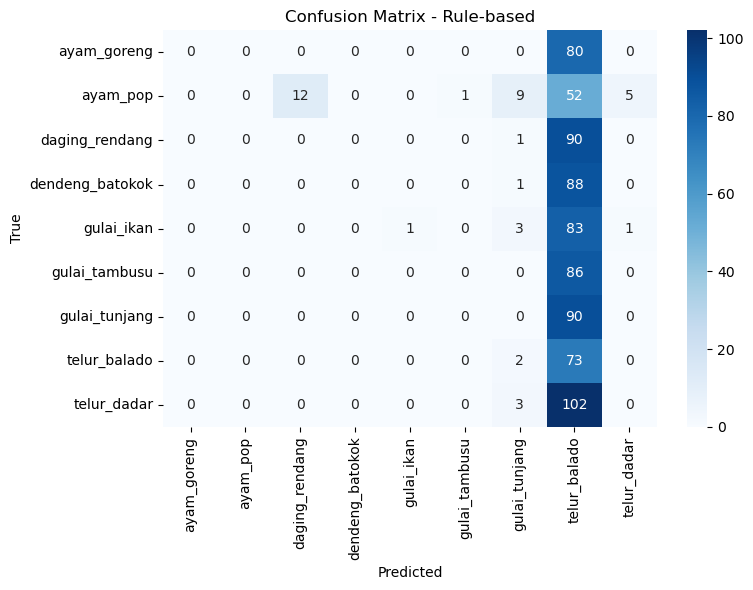

Selesai baseline rule-based. Metrics: 0.09450830140485313 0.02230423204205976


In [50]:
# Jalankan baseline rule-based
seg_method = segmentation_method if use_segmentation else None
rule_dataset = build_rule_dataset(all_paths, seg_method=seg_method)
print(f'Total sampel diuji: {len(rule_dataset)}')
baseline_metrics = evaluate_rule_based(rule_dataset)
print('Selesai baseline rule-based. Metrics:', baseline_metrics['accuracy'], baseline_metrics['macro_f1'])
